In [18]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [88]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Đang sử dụng GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [119]:
# ----- Cấu hình -----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0004
epochs = 300

In [120]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [121]:
# ----- Mạng Generator -----
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 28*28),
            nn.Tanh()  # output lung range [-1,1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, 28, 28)
        return img

# ----- Mạng Discriminator -----
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()  # output xác suất
        )

    def forward(self, img):
        return self.model(img)

In [122]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [123]:
# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_D: 0.1816, Loss_G: 2.3521, Time: 15.52s


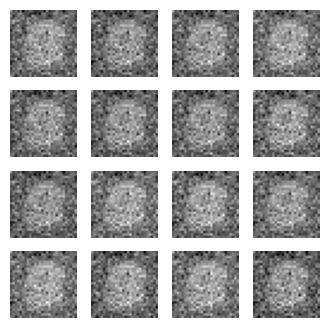

[Epoch 2/300] Loss_D: 0.0682, Loss_G: 4.8892, Time: 31.49s
[Epoch 3/300] Loss_D: 0.0941, Loss_G: 7.3665, Time: 48.11s
[Epoch 4/300] Loss_D: 0.2627, Loss_G: 5.1511, Time: 65.11s
[Epoch 5/300] Loss_D: 0.3018, Loss_G: 5.8583, Time: 81.82s
[Epoch 6/300] Loss_D: 0.4251, Loss_G: 4.8912, Time: 98.12s
[Epoch 7/300] Loss_D: 0.4575, Loss_G: 3.3186, Time: 113.89s
[Epoch 8/300] Loss_D: 0.4774, Loss_G: 1.8340, Time: 129.57s
[Epoch 9/300] Loss_D: 0.4980, Loss_G: 2.6736, Time: 144.88s
[Epoch 10/300] Loss_D: 0.5359, Loss_G: 1.8605, Time: 160.24s
[Epoch 11/300] Loss_D: 0.4065, Loss_G: 2.2619, Time: 175.15s
[Epoch 12/300] Loss_D: 0.3517, Loss_G: 2.5441, Time: 189.87s
[Epoch 13/300] Loss_D: 0.4081, Loss_G: 3.3410, Time: 204.73s
[Epoch 14/300] Loss_D: 0.3294, Loss_G: 4.5305, Time: 221.28s
[Epoch 15/300] Loss_D: 0.4153, Loss_G: 3.2872, Time: 238.70s
[Epoch 16/300] Loss_D: 0.4620, Loss_G: 3.3864, Time: 255.85s
[Epoch 17/300] Loss_D: 0.2947, Loss_G: 3.6869, Time: 272.07s
[Epoch 18/300] Loss_D: 0.4248, Loss_G

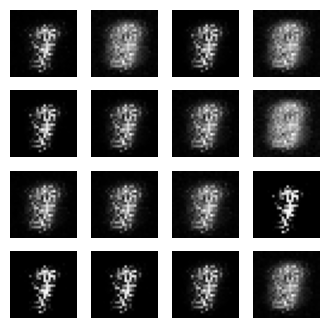

[Epoch 21/300] Loss_D: 0.4957, Loss_G: 2.6285, Time: 332.98s
[Epoch 22/300] Loss_D: 0.4522, Loss_G: 3.0248, Time: 347.82s
[Epoch 23/300] Loss_D: 0.4469, Loss_G: 2.7052, Time: 362.12s
[Epoch 24/300] Loss_D: 0.4907, Loss_G: 2.6559, Time: 376.81s
[Epoch 25/300] Loss_D: 0.4855, Loss_G: 2.1232, Time: 392.65s
[Epoch 26/300] Loss_D: 0.3355, Loss_G: 2.5462, Time: 408.78s
[Epoch 27/300] Loss_D: 0.2736, Loss_G: 2.7029, Time: 425.24s
[Epoch 28/300] Loss_D: 0.3541, Loss_G: 3.1750, Time: 441.32s
[Epoch 29/300] Loss_D: 0.3307, Loss_G: 4.7550, Time: 457.54s
[Epoch 30/300] Loss_D: 0.1989, Loss_G: 3.8033, Time: 473.04s
[Epoch 31/300] Loss_D: 0.2641, Loss_G: 3.1592, Time: 487.84s
[Epoch 32/300] Loss_D: 0.2566, Loss_G: 3.2586, Time: 502.41s
[Epoch 33/300] Loss_D: 0.3004, Loss_G: 2.8013, Time: 516.86s
[Epoch 34/300] Loss_D: 0.3236, Loss_G: 3.0395, Time: 531.17s
[Epoch 35/300] Loss_D: 0.2239, Loss_G: 3.5329, Time: 546.03s
[Epoch 36/300] Loss_D: 0.2290, Loss_G: 2.6764, Time: 560.29s
[Epoch 37/300] Loss_D: 0

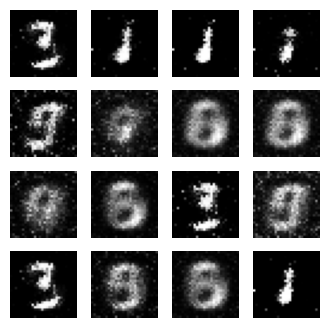

[Epoch 41/300] Loss_D: 0.2757, Loss_G: 2.6403, Time: 635.47s
[Epoch 42/300] Loss_D: 0.3167, Loss_G: 3.0936, Time: 650.49s
[Epoch 43/300] Loss_D: 0.2646, Loss_G: 3.4109, Time: 665.24s
[Epoch 44/300] Loss_D: 0.2882, Loss_G: 3.7020, Time: 679.96s
[Epoch 45/300] Loss_D: 0.3791, Loss_G: 3.9595, Time: 694.92s
[Epoch 46/300] Loss_D: 0.3488, Loss_G: 3.5479, Time: 709.57s
[Epoch 47/300] Loss_D: 0.3319, Loss_G: 2.6476, Time: 723.95s
[Epoch 48/300] Loss_D: 0.3156, Loss_G: 2.8679, Time: 738.82s
[Epoch 49/300] Loss_D: 0.2716, Loss_G: 2.9866, Time: 754.18s
[Epoch 50/300] Loss_D: 0.2495, Loss_G: 3.0556, Time: 770.32s
[Epoch 51/300] Loss_D: 0.2936, Loss_G: 3.3075, Time: 786.38s
[Epoch 52/300] Loss_D: 0.3143, Loss_G: 3.6255, Time: 801.98s
[Epoch 53/300] Loss_D: 0.2929, Loss_G: 3.7551, Time: 817.97s
[Epoch 54/300] Loss_D: 0.3133, Loss_G: 3.6563, Time: 833.23s
[Epoch 55/300] Loss_D: 0.3162, Loss_G: 3.7813, Time: 847.24s
[Epoch 56/300] Loss_D: 0.2954, Loss_G: 3.3452, Time: 860.95s
[Epoch 57/300] Loss_D: 0

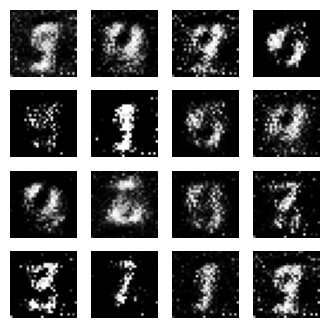

[Epoch 61/300] Loss_D: 0.2374, Loss_G: 3.6737, Time: 931.12s
[Epoch 62/300] Loss_D: 0.2555, Loss_G: 3.2742, Time: 946.14s
[Epoch 63/300] Loss_D: 0.2489, Loss_G: 3.4006, Time: 962.12s
[Epoch 64/300] Loss_D: 0.2126, Loss_G: 3.6677, Time: 978.28s
[Epoch 65/300] Loss_D: 0.2017, Loss_G: 3.7504, Time: 994.60s
[Epoch 66/300] Loss_D: 0.2681, Loss_G: 3.6673, Time: 1009.88s
[Epoch 67/300] Loss_D: 0.2181, Loss_G: 4.2020, Time: 1024.00s
[Epoch 68/300] Loss_D: 0.2398, Loss_G: 4.5728, Time: 1038.08s
[Epoch 69/300] Loss_D: 0.2256, Loss_G: 5.5169, Time: 1052.05s
[Epoch 70/300] Loss_D: 0.2320, Loss_G: 4.5583, Time: 1065.80s
[Epoch 71/300] Loss_D: 0.2265, Loss_G: 3.8706, Time: 1080.80s
[Epoch 72/300] Loss_D: 0.2391, Loss_G: 3.5565, Time: 1095.63s
[Epoch 73/300] Loss_D: 0.2408, Loss_G: 3.3380, Time: 1110.20s
[Epoch 74/300] Loss_D: 0.2194, Loss_G: 3.6423, Time: 1125.84s
[Epoch 75/300] Loss_D: 0.2232, Loss_G: 4.1230, Time: 1141.64s
[Epoch 76/300] Loss_D: 0.2000, Loss_G: 3.4542, Time: 1157.58s
[Epoch 77/300

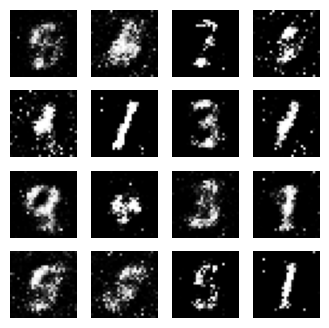

[Epoch 81/300] Loss_D: 0.2227, Loss_G: 3.3913, Time: 1233.64s
[Epoch 82/300] Loss_D: 0.2598, Loss_G: 3.1004, Time: 1247.97s
[Epoch 83/300] Loss_D: 0.2381, Loss_G: 3.5502, Time: 1262.37s
[Epoch 84/300] Loss_D: 0.2702, Loss_G: 3.7903, Time: 1277.02s
[Epoch 85/300] Loss_D: 0.2687, Loss_G: 3.2752, Time: 1291.57s
[Epoch 86/300] Loss_D: 0.2759, Loss_G: 3.1306, Time: 1307.86s
[Epoch 87/300] Loss_D: 0.2916, Loss_G: 3.1849, Time: 1324.14s
[Epoch 88/300] Loss_D: 0.2956, Loss_G: 3.4318, Time: 1340.48s
[Epoch 89/300] Loss_D: 0.2505, Loss_G: 3.5220, Time: 1356.73s
[Epoch 90/300] Loss_D: 0.2568, Loss_G: 2.9206, Time: 1372.61s
[Epoch 91/300] Loss_D: 0.2708, Loss_G: 2.9530, Time: 1386.88s
[Epoch 92/300] Loss_D: 0.2675, Loss_G: 2.9231, Time: 1401.67s
[Epoch 93/300] Loss_D: 0.2636, Loss_G: 3.0939, Time: 1416.54s
[Epoch 94/300] Loss_D: 0.2685, Loss_G: 3.1255, Time: 1431.63s
[Epoch 95/300] Loss_D: 0.2633, Loss_G: 3.4186, Time: 1446.17s
[Epoch 96/300] Loss_D: 0.2731, Loss_G: 3.2736, Time: 1460.14s
[Epoch 9

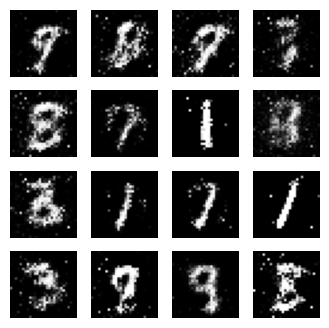

[Epoch 101/300] Loss_D: 0.2903, Loss_G: 3.0462, Time: 1531.66s
[Epoch 102/300] Loss_D: 0.2571, Loss_G: 3.0608, Time: 1544.76s
[Epoch 103/300] Loss_D: 0.2349, Loss_G: 3.1330, Time: 1558.42s
[Epoch 104/300] Loss_D: 0.2430, Loss_G: 3.1492, Time: 1571.12s
[Epoch 105/300] Loss_D: 0.2441, Loss_G: 3.2067, Time: 1583.76s
[Epoch 106/300] Loss_D: 0.2587, Loss_G: 3.0812, Time: 1596.67s
[Epoch 107/300] Loss_D: 0.2473, Loss_G: 3.1584, Time: 1609.00s
[Epoch 108/300] Loss_D: 0.2686, Loss_G: 3.1056, Time: 1621.14s
[Epoch 109/300] Loss_D: 0.2748, Loss_G: 3.1353, Time: 1633.32s
[Epoch 110/300] Loss_D: 0.2612, Loss_G: 2.9799, Time: 1645.73s
[Epoch 111/300] Loss_D: 0.2725, Loss_G: 2.9567, Time: 1658.01s
[Epoch 112/300] Loss_D: 0.2650, Loss_G: 3.0664, Time: 1671.41s
[Epoch 113/300] Loss_D: 0.2868, Loss_G: 2.8435, Time: 1685.13s
[Epoch 114/300] Loss_D: 0.2701, Loss_G: 2.8054, Time: 1698.64s
[Epoch 115/300] Loss_D: 0.2837, Loss_G: 2.9301, Time: 1712.71s
[Epoch 116/300] Loss_D: 0.2739, Loss_G: 2.9659, Time: 1

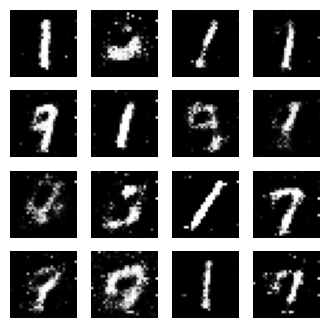

[Epoch 121/300] Loss_D: 0.2896, Loss_G: 2.9925, Time: 1869.83s
[Epoch 122/300] Loss_D: 0.2777, Loss_G: 2.8979, Time: 1878.10s
[Epoch 123/300] Loss_D: 0.2949, Loss_G: 2.6689, Time: 1885.83s
[Epoch 124/300] Loss_D: 0.2786, Loss_G: 2.7251, Time: 1893.76s
[Epoch 125/300] Loss_D: 0.2902, Loss_G: 2.7558, Time: 1902.09s
[Epoch 126/300] Loss_D: 0.2749, Loss_G: 2.9042, Time: 1916.53s
[Epoch 127/300] Loss_D: 0.2884, Loss_G: 2.8976, Time: 1930.84s
[Epoch 128/300] Loss_D: 0.3013, Loss_G: 2.8182, Time: 1938.32s
[Epoch 129/300] Loss_D: 0.3139, Loss_G: 2.7143, Time: 1945.82s
[Epoch 130/300] Loss_D: 0.3046, Loss_G: 2.6083, Time: 1957.17s
[Epoch 131/300] Loss_D: 0.3122, Loss_G: 2.5427, Time: 1972.31s
[Epoch 132/300] Loss_D: 0.3095, Loss_G: 2.5484, Time: 1994.63s
[Epoch 133/300] Loss_D: 0.3167, Loss_G: 2.4769, Time: 2043.29s
[Epoch 134/300] Loss_D: 0.3255, Loss_G: 2.4132, Time: 2072.55s
[Epoch 135/300] Loss_D: 0.3154, Loss_G: 2.5730, Time: 2114.94s
[Epoch 136/300] Loss_D: 0.3147, Loss_G: 2.7117, Time: 2

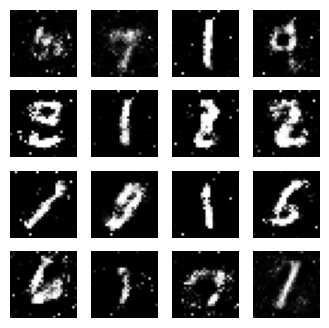

[Epoch 141/300] Loss_D: 0.3124, Loss_G: 2.5138, Time: 2234.96s
[Epoch 142/300] Loss_D: 0.3364, Loss_G: 2.5467, Time: 2277.24s
[Epoch 143/300] Loss_D: 0.3188, Loss_G: 2.4648, Time: 2301.17s
[Epoch 144/300] Loss_D: 0.3393, Loss_G: 2.4327, Time: 2355.27s
[Epoch 145/300] Loss_D: 0.3197, Loss_G: 2.5010, Time: 2409.01s
[Epoch 146/300] Loss_D: 0.3318, Loss_G: 2.4686, Time: 2470.05s
[Epoch 147/300] Loss_D: 0.3282, Loss_G: 2.4831, Time: 2495.88s
[Epoch 148/300] Loss_D: 0.3267, Loss_G: 2.5368, Time: 2532.47s
[Epoch 149/300] Loss_D: 0.3326, Loss_G: 2.5445, Time: 2587.98s
[Epoch 150/300] Loss_D: 0.3264, Loss_G: 2.5398, Time: 2635.23s
[Epoch 151/300] Loss_D: 0.3237, Loss_G: 2.3955, Time: 2672.13s
[Epoch 152/300] Loss_D: 0.3247, Loss_G: 2.4714, Time: 2691.28s
[Epoch 153/300] Loss_D: 0.3260, Loss_G: 2.5368, Time: 2708.08s
[Epoch 154/300] Loss_D: 0.3301, Loss_G: 2.4726, Time: 2726.06s
[Epoch 155/300] Loss_D: 0.3387, Loss_G: 2.5230, Time: 2743.39s
[Epoch 156/300] Loss_D: 0.3316, Loss_G: 2.4384, Time: 2

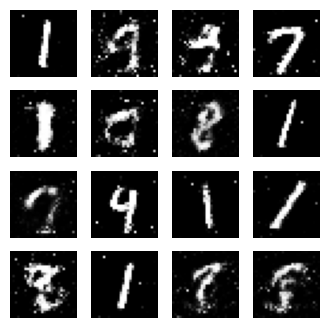

[Epoch 161/300] Loss_D: 0.3505, Loss_G: 2.3802, Time: 2849.01s
[Epoch 162/300] Loss_D: 0.3478, Loss_G: 2.3508, Time: 2866.71s
[Epoch 163/300] Loss_D: 0.3571, Loss_G: 2.3167, Time: 2883.50s
[Epoch 164/300] Loss_D: 0.3493, Loss_G: 2.3540, Time: 2901.87s
[Epoch 165/300] Loss_D: 0.3547, Loss_G: 2.3612, Time: 2920.94s
[Epoch 166/300] Loss_D: 0.3501, Loss_G: 2.3229, Time: 2939.27s
[Epoch 167/300] Loss_D: 0.3482, Loss_G: 2.3004, Time: 2957.69s
[Epoch 168/300] Loss_D: 0.3526, Loss_G: 2.2842, Time: 2975.81s
[Epoch 169/300] Loss_D: 0.3466, Loss_G: 2.2652, Time: 2994.06s
[Epoch 170/300] Loss_D: 0.3651, Loss_G: 2.2972, Time: 3011.60s
[Epoch 171/300] Loss_D: 0.3670, Loss_G: 2.4017, Time: 3029.26s
[Epoch 172/300] Loss_D: 0.3500, Loss_G: 2.4158, Time: 3047.69s
[Epoch 173/300] Loss_D: 0.3663, Loss_G: 2.3032, Time: 3066.14s
[Epoch 174/300] Loss_D: 0.3617, Loss_G: 2.1983, Time: 3084.57s
[Epoch 175/300] Loss_D: 0.3863, Loss_G: 2.2354, Time: 3102.64s
[Epoch 176/300] Loss_D: 0.3508, Loss_G: 2.3102, Time: 3

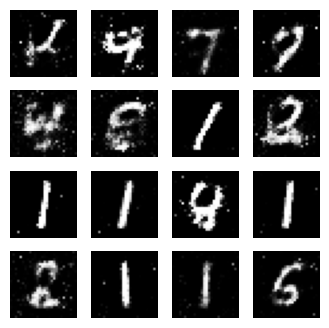

[Epoch 181/300] Loss_D: 0.3876, Loss_G: 2.0389, Time: 3214.95s
[Epoch 182/300] Loss_D: 0.3838, Loss_G: 2.1723, Time: 3233.09s
[Epoch 183/300] Loss_D: 0.3781, Loss_G: 2.1659, Time: 3252.56s
[Epoch 184/300] Loss_D: 0.3934, Loss_G: 2.0485, Time: 3270.17s
[Epoch 185/300] Loss_D: 0.3849, Loss_G: 2.0845, Time: 3289.04s
[Epoch 186/300] Loss_D: 0.3896, Loss_G: 2.0820, Time: 3307.55s
[Epoch 187/300] Loss_D: 0.3970, Loss_G: 2.0346, Time: 3326.52s
[Epoch 188/300] Loss_D: 0.3961, Loss_G: 2.0707, Time: 3345.57s
[Epoch 189/300] Loss_D: 0.3956, Loss_G: 2.0467, Time: 3365.71s
[Epoch 190/300] Loss_D: 0.3919, Loss_G: 2.1728, Time: 3383.83s
[Epoch 191/300] Loss_D: 0.3924, Loss_G: 2.1846, Time: 3401.88s
[Epoch 192/300] Loss_D: 0.3997, Loss_G: 2.0118, Time: 3419.52s
[Epoch 193/300] Loss_D: 0.3964, Loss_G: 2.0479, Time: 3435.72s
[Epoch 194/300] Loss_D: 0.4051, Loss_G: 2.0033, Time: 3452.54s
[Epoch 195/300] Loss_D: 0.3858, Loss_G: 2.0039, Time: 3469.55s
[Epoch 196/300] Loss_D: 0.4023, Loss_G: 2.0106, Time: 3

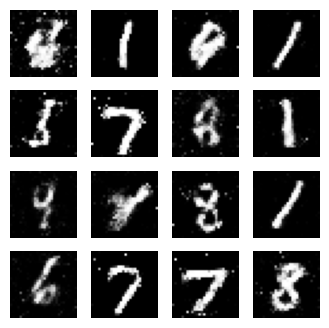

[Epoch 201/300] Loss_D: 0.4157, Loss_G: 1.9807, Time: 3571.93s
[Epoch 202/300] Loss_D: 0.4050, Loss_G: 1.9981, Time: 3589.89s
[Epoch 203/300] Loss_D: 0.4156, Loss_G: 1.9529, Time: 3606.24s
[Epoch 204/300] Loss_D: 0.4189, Loss_G: 1.8915, Time: 3623.47s
[Epoch 205/300] Loss_D: 0.4071, Loss_G: 1.9323, Time: 3642.02s
[Epoch 206/300] Loss_D: 0.4189, Loss_G: 1.8598, Time: 3659.91s
[Epoch 207/300] Loss_D: 0.4191, Loss_G: 1.8448, Time: 3678.60s
[Epoch 208/300] Loss_D: 0.4176, Loss_G: 1.9259, Time: 3697.62s
[Epoch 209/300] Loss_D: 0.4172, Loss_G: 1.9664, Time: 3716.66s
[Epoch 210/300] Loss_D: 0.4182, Loss_G: 1.9287, Time: 3734.96s
[Epoch 211/300] Loss_D: 0.4230, Loss_G: 1.9004, Time: 3752.95s
[Epoch 212/300] Loss_D: 0.4287, Loss_G: 1.8841, Time: 3771.19s
[Epoch 213/300] Loss_D: 0.4287, Loss_G: 1.8528, Time: 3788.90s
[Epoch 214/300] Loss_D: 0.4200, Loss_G: 1.8422, Time: 3809.96s
[Epoch 215/300] Loss_D: 0.4222, Loss_G: 1.8749, Time: 3828.08s
[Epoch 216/300] Loss_D: 0.4238, Loss_G: 1.9274, Time: 3

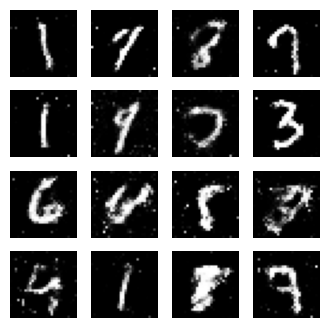

[Epoch 221/300] Loss_D: 0.4257, Loss_G: 1.7921, Time: 3940.28s
[Epoch 222/300] Loss_D: 0.4285, Loss_G: 1.8670, Time: 3960.24s
[Epoch 223/300] Loss_D: 0.4304, Loss_G: 1.9339, Time: 3978.97s
[Epoch 224/300] Loss_D: 0.4342, Loss_G: 1.8464, Time: 3997.05s
[Epoch 225/300] Loss_D: 0.4262, Loss_G: 1.8221, Time: 4015.12s
[Epoch 226/300] Loss_D: 0.4287, Loss_G: 1.8441, Time: 4033.41s
[Epoch 227/300] Loss_D: 0.4337, Loss_G: 1.7787, Time: 4052.91s
[Epoch 228/300] Loss_D: 0.4239, Loss_G: 1.8198, Time: 4071.81s
[Epoch 229/300] Loss_D: 0.4331, Loss_G: 1.8508, Time: 4091.18s
[Epoch 230/300] Loss_D: 0.4457, Loss_G: 1.8052, Time: 4111.15s
[Epoch 231/300] Loss_D: 0.4287, Loss_G: 1.7853, Time: 4132.09s
[Epoch 232/300] Loss_D: 0.4366, Loss_G: 1.7856, Time: 4152.45s
[Epoch 233/300] Loss_D: 0.4388, Loss_G: 1.8530, Time: 4172.24s
[Epoch 234/300] Loss_D: 0.4455, Loss_G: 1.7663, Time: 4191.47s
[Epoch 235/300] Loss_D: 0.4325, Loss_G: 1.8179, Time: 4211.35s
[Epoch 236/300] Loss_D: 0.4404, Loss_G: 1.7608, Time: 4

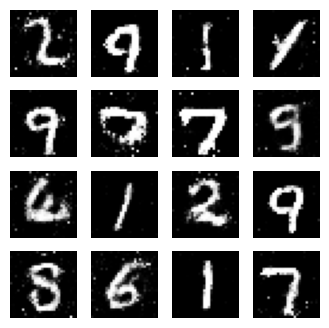

[Epoch 241/300] Loss_D: 0.4575, Loss_G: 1.7240, Time: 4327.79s
[Epoch 242/300] Loss_D: 0.4490, Loss_G: 1.6712, Time: 4345.83s
[Epoch 243/300] Loss_D: 0.4432, Loss_G: 1.6789, Time: 4364.97s
[Epoch 244/300] Loss_D: 0.4445, Loss_G: 1.6996, Time: 4387.18s
[Epoch 245/300] Loss_D: 0.4351, Loss_G: 1.7414, Time: 4430.74s
[Epoch 246/300] Loss_D: 0.4406, Loss_G: 1.8659, Time: 4483.36s
[Epoch 247/300] Loss_D: 0.4345, Loss_G: 1.8964, Time: 4538.35s
[Epoch 248/300] Loss_D: 0.4485, Loss_G: 1.7454, Time: 4587.50s
[Epoch 249/300] Loss_D: 0.4362, Loss_G: 1.6790, Time: 4623.85s
[Epoch 250/300] Loss_D: 0.4436, Loss_G: 1.7443, Time: 4679.03s
[Epoch 251/300] Loss_D: 0.4475, Loss_G: 1.8339, Time: 4717.41s
[Epoch 252/300] Loss_D: 0.4430, Loss_G: 1.7298, Time: 4735.72s
[Epoch 253/300] Loss_D: 0.4480, Loss_G: 1.7574, Time: 4752.64s
[Epoch 254/300] Loss_D: 0.4424, Loss_G: 1.7973, Time: 4770.29s
[Epoch 255/300] Loss_D: 0.4421, Loss_G: 1.7401, Time: 4786.33s
[Epoch 256/300] Loss_D: 0.4445, Loss_G: 1.7565, Time: 4

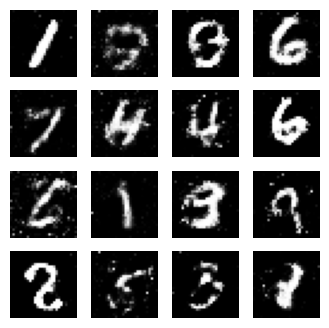

[Epoch 261/300] Loss_D: 0.4594, Loss_G: 1.7423, Time: 4886.67s
[Epoch 262/300] Loss_D: 0.4418, Loss_G: 1.7464, Time: 4903.15s
[Epoch 263/300] Loss_D: 0.4483, Loss_G: 1.7486, Time: 4918.70s
[Epoch 264/300] Loss_D: 0.4681, Loss_G: 1.6984, Time: 4934.32s
[Epoch 265/300] Loss_D: 0.4536, Loss_G: 1.6488, Time: 4950.56s
[Epoch 266/300] Loss_D: 0.4536, Loss_G: 1.6728, Time: 4967.30s
[Epoch 267/300] Loss_D: 0.4473, Loss_G: 1.7453, Time: 4983.34s
[Epoch 268/300] Loss_D: 0.4687, Loss_G: 1.7073, Time: 4999.70s
[Epoch 269/300] Loss_D: 0.4503, Loss_G: 1.7300, Time: 5015.77s
[Epoch 270/300] Loss_D: 0.4554, Loss_G: 1.7006, Time: 5034.42s
[Epoch 271/300] Loss_D: 0.4539, Loss_G: 1.6065, Time: 5052.59s
[Epoch 272/300] Loss_D: 0.4543, Loss_G: 1.5838, Time: 5070.18s
[Epoch 273/300] Loss_D: 0.4649, Loss_G: 1.6601, Time: 5088.12s
[Epoch 274/300] Loss_D: 0.4600, Loss_G: 1.7018, Time: 5104.18s
[Epoch 275/300] Loss_D: 0.4583, Loss_G: 1.6517, Time: 5120.41s
[Epoch 276/300] Loss_D: 0.4609, Loss_G: 1.7710, Time: 5

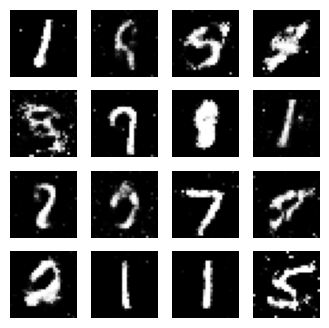

[Epoch 281/300] Loss_D: 0.4696, Loss_G: 1.6006, Time: 5219.65s
[Epoch 282/300] Loss_D: 0.4625, Loss_G: 1.6406, Time: 5236.51s
[Epoch 283/300] Loss_D: 0.4562, Loss_G: 1.6488, Time: 5252.81s
[Epoch 284/300] Loss_D: 0.4612, Loss_G: 1.6744, Time: 5269.03s
[Epoch 285/300] Loss_D: 0.4646, Loss_G: 1.6846, Time: 5285.38s
[Epoch 286/300] Loss_D: 0.4565, Loss_G: 1.6210, Time: 5301.70s
[Epoch 287/300] Loss_D: 0.4679, Loss_G: 1.6266, Time: 5318.25s
[Epoch 288/300] Loss_D: 0.4720, Loss_G: 1.7437, Time: 5334.79s
[Epoch 289/300] Loss_D: 0.4614, Loss_G: 1.8547, Time: 5352.60s
[Epoch 290/300] Loss_D: 0.4602, Loss_G: 1.7396, Time: 5370.70s
[Epoch 291/300] Loss_D: 0.4757, Loss_G: 1.6822, Time: 5388.82s
[Epoch 292/300] Loss_D: 0.4617, Loss_G: 1.5949, Time: 5406.67s
[Epoch 293/300] Loss_D: 0.4620, Loss_G: 1.5880, Time: 5423.81s
[Epoch 294/300] Loss_D: 0.4556, Loss_G: 1.5875, Time: 5441.63s
[Epoch 295/300] Loss_D: 0.4643, Loss_G: 1.5893, Time: 5459.21s
[Epoch 296/300] Loss_D: 0.4532, Loss_G: 1.6402, Time: 5

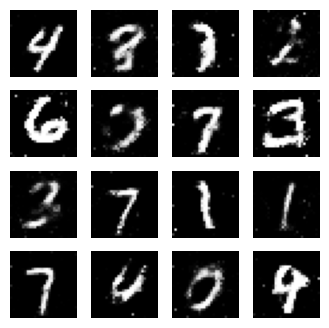

In [124]:
t0 = time.perf_counter()  # High-resolution timer
for epoch in range(1, epochs + 1):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)
        valid = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # -- Discriminator
        optimizer_D.zero_grad()
        loss_real = criterion(discriminator(real_imgs), valid)
        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)
        loss_fake = criterion(discriminator(gen_imgs.detach()), fake)
        loss_D = (loss_real + loss_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # -- Generator
        optimizer_G.zero_grad()
        loss_G = criterion(discriminator(gen_imgs), valid)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_D'].append(avg_loss_D)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    print(f"[Epoch {epoch}/{epochs}] Loss_D: {avg_loss_D:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            test_imgs = generator(test_z).cpu()
            fig, axes = plt.subplots(4, 4, figsize=(4, 4))
            for img, ax in zip(test_imgs, axes.flatten()):
                ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.show()

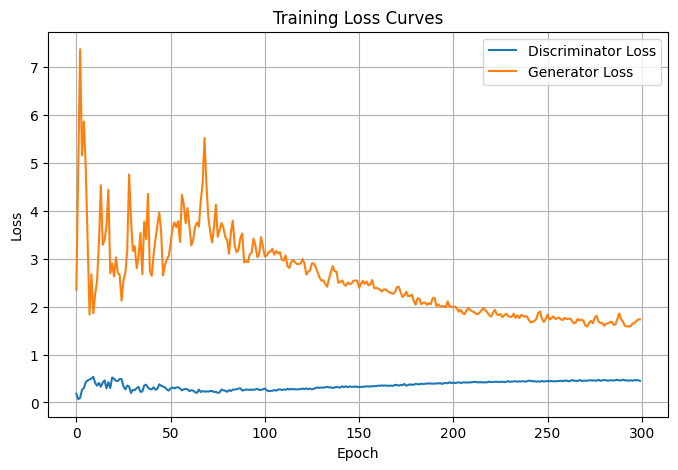

In [126]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_D'], label='Discriminator Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

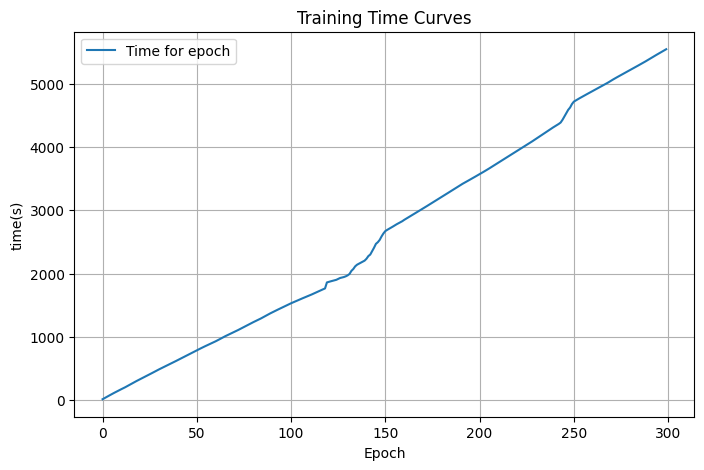

In [130]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [132]:
# Export to CSV
csv_file = 'GAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to GAN_training_history.csv
